In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import folium
import warnings
warnings.filterwarnings('ignore')

# Dataset luoghi storici VOC e pre-VOC ad Amsterdam
luoghi_voc = {
    'nome': [
        'Oost-Indisch Huis',
        'West-Indisch Huis', 
        'Entrepotdok',
        'Scheepvaartshuis',
        'VOC Magazijn — Oostenburg',
        'Beurs van Berlage',
        'Waag (Sint-Antonieswaag)',
        'Montelbaanstoren',
        'Admiraliteitshuis',
        'Oostindisch Archipel'
    ],
    'anno': [1606, 1617, 1708, 1916, 1661, 1903, 1488, 1516, 1656, 1660],
    'tipo': [
        'VOC', 'WIC', 'VOC', 'Navigazione', 
        'VOC', 'Finanza', 'Pre-VOC', 'Pre-VOC', 'VOC', 'VOC'
    ],
    'descrizione': [
        'Sede centrale della VOC — Vereenigde Oostindische Compagnie (1602-1799)',
        'Sede della WIC — qui nel 1626 fu firmato l\'acquisto di Manhattan',
        'Complesso di magazzini VOC — oggi convertiti in appartamenti',
        'Casa della navigazione — simbolo del commercio marittimo olandese',
        'Magazzini VOC sull\'isola di Oostenburg — cuore della logistica coloniale',
        'Borsa di Amsterdam — costruita sul sito della prima borsa del mondo (1611)',
        'Antica porta della città — qui transitavano le merci pre-VOC',
        'Torre di guardia del porto medievale — 1516, prima della VOC',
        'Sede dell\'Ammiragliato — coordinava la flotta commerciale e militare',
        'Quartiere dei magazzini orientali — spezie, seta, porcellana'
    ],
    'lat': [
        52.3706, 52.3742, 52.3681, 52.3764,
        52.3695, 52.3733, 52.3726, 52.3724,
        52.3689, 52.3672
    ],
    'lng': [
        4.8998, 4.8908, 4.9201, 4.9001,
        4.9178, 4.8951, 4.9005, 4.9065,
        4.9089, 4.9156
    ]
}

df_voc = pd.DataFrame(luoghi_voc)
print(f"Luoghi storici caricati: {len(df_voc)}")
print(df_voc[['nome', 'anno', 'tipo']])

Luoghi storici caricati: 10
                        nome  anno         tipo
0          Oost-Indisch Huis  1606          VOC
1          West-Indisch Huis  1617          WIC
2                Entrepotdok  1708          VOC
3           Scheepvaartshuis  1916  Navigazione
4  VOC Magazijn — Oostenburg  1661          VOC
5          Beurs van Berlage  1903      Finanza
6   Waag (Sint-Antonieswaag)  1488      Pre-VOC
7           Montelbaanstoren  1516      Pre-VOC
8          Admiraliteitshuis  1656          VOC
9       Oostindisch Archipel  1660          VOC


In [2]:
# Carichiamo gli edifici e filtriamo il Secolo d'Oro
gdf = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\geojson_lnglat.json",
                    on_invalid="ignore")

# Edifici del Secolo d'Oro (1600-1700)
secolo_oro = gdf[(gdf['Bouwjaar'] >= 1600) & (gdf['Bouwjaar'] <= 1700)].copy()
# Edifici pre-VOC (1500-1599)
pre_voc = gdf[(gdf['Bouwjaar'] >= 1500) & (gdf['Bouwjaar'] < 1600)].copy()

print(f"Edifici Secolo d'Oro (1600-1700): {len(secolo_oro)}")
print(f"Edifici pre-VOC (1500-1599): {len(pre_voc)}")

Edifici Secolo d'Oro (1600-1700): 1265
Edifici pre-VOC (1500-1599): 23


In [3]:
# Mappa interattiva VOC
m = folium.Map(location=[52.3728, 4.9020], zoom_start=14, tiles='CartoDB positron')

# --- LAYER 1: Edifici pre-VOC (1500-1599) ---
pre_voc_layer = folium.FeatureGroup(name='Pre-VOC Buildings (1500-1599)', show=True)
for _, row in pre_voc.iterrows():
    folium.GeoJson(
        row['geometry'].__geo_interface__,
        style_function=lambda x: {
            'fillColor': '#8B4513',
            'color': '#8B4513',
            'weight': 0.5,
            'fillOpacity': 0.8
        },
        tooltip=f"Anno: {int(row['Bouwjaar'])}"
    ).add_to(pre_voc_layer)
pre_voc_layer.add_to(m)

# --- LAYER 2: Edifici Secolo d'Oro (1600-1700) ---
oro_layer = folium.FeatureGroup(name="Golden Age Buildings (1600-1700)", show=True)
for _, row in secolo_oro.iterrows():
    folium.GeoJson(
        row['geometry'].__geo_interface__,
        style_function=lambda x: {
            'fillColor': '#DAA520',
            'color': '#B8860B',
            'weight': 0.3,
            'fillOpacity': 0.7
        },
        tooltip=f"Anno: {int(row['Bouwjaar'])}"
    ).add_to(oro_layer)
oro_layer.add_to(m)

# --- LAYER 3: Luoghi storici VOC ---
colori_tipo = {
    'VOC': '#C0392B',
    'WIC': '#8E44AD',
    'Pre-VOC': '#2C3E50',
    'Navigazione': '#2980B9',
    'Finanza': '#27AE60'
}

voc_layer = folium.FeatureGroup(name='VOC & Historic Sites', show=True)
for _, row in df_voc.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=10,
        color=colori_tipo.get(row['tipo'], '#E74C3C'),
        fill=True,
        fill_color=colori_tipo.get(row['tipo'], '#E74C3C'),
        fill_opacity=0.9,
        tooltip=f"<b>{row['nome']}</b><br>{row['anno']}<br>{row['descrizione']}"
    ).add_to(voc_layer)
voc_layer.add_to(m)

# Controllo layer
folium.LayerControl(collapsed=False).add_to(m)

m.save('amsterdam_voc_map.html')
print("Mappa VOC salvata!")

Mappa VOC salvata!


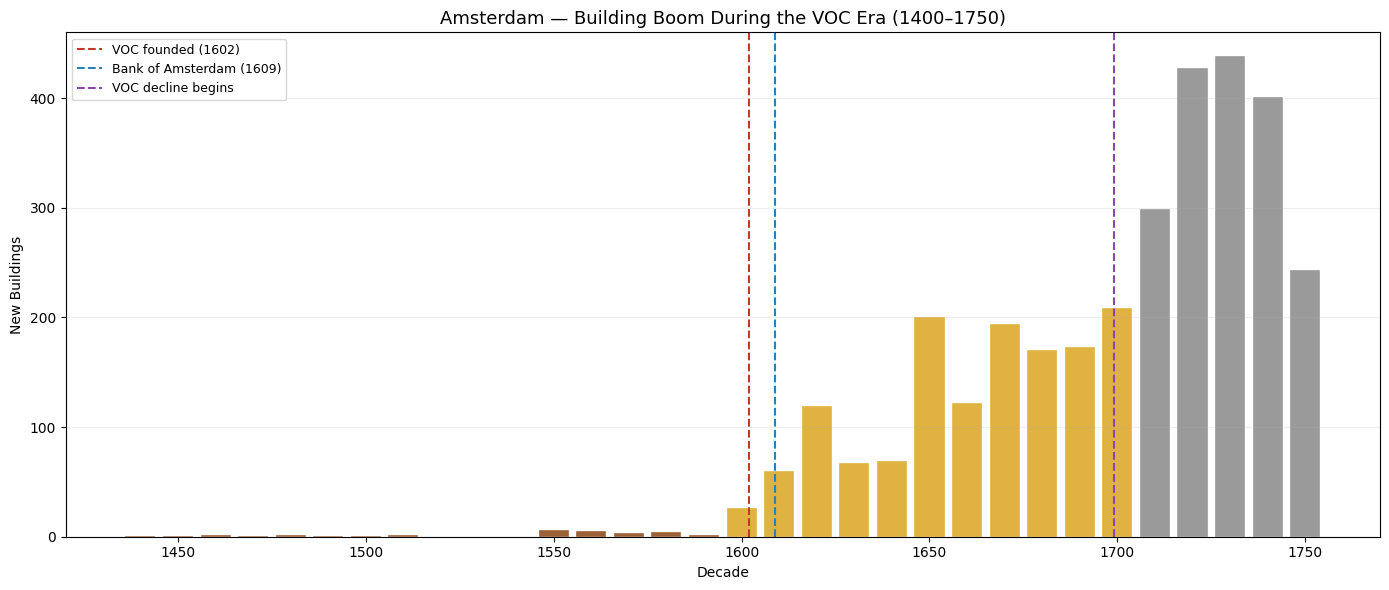

In [4]:
import matplotlib.pyplot as plt

# Raggruppiamo per decennio
gdf_clean = gdf[(gdf['Bouwjaar'] >= 1400) & (gdf['Bouwjaar'] <= 1750)].copy()
gdf_clean['Decennio'] = (gdf_clean['Bouwjaar'] // 10) * 10
per_decennio = gdf_clean.groupby('Decennio').size().reset_index()
per_decennio.columns = ['Decennio', 'Edifici']

fig, ax = plt.subplots(figsize=(14, 6))

colori = ['#DAA520' if 1600 <= d <= 1700 else '#8B4513' if d < 1600 else '#888888' 
          for d in per_decennio['Decennio']]

ax.bar(per_decennio['Decennio'], per_decennio['Edifici'],
       width=8, color=colori, alpha=0.85, edgecolor='white', linewidth=0.3)

# Linee verticali per eventi chiave
ax.axvline(x=1602, color='#C0392B', linestyle='--', linewidth=1.5, label='VOC founded (1602)')
ax.axvline(x=1609, color='#2980B9', linestyle='--', linewidth=1.5, label='Bank of Amsterdam (1609)')
ax.axvline(x=1699, color='#8E44AD', linestyle='--', linewidth=1.5, label='VOC decline begins')

ax.set_title("Amsterdam — Building Boom During the VOC Era (1400–1750)", fontsize=13)
ax.set_xlabel('Decade')
ax.set_ylabel('New Buildings')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('amsterdam_voc_boom.png', dpi=150, bbox_inches='tight')
plt.show()